# Q4: Which categories of problems are most common in Zurich? 
This question looks at which category of problem has to most reports related to it. The anticipated workflow is:

0. Import all packages and functions needed
1. Import the data needed
2. Calculate the number of reports per category
3. Create a table of the result
4. Create a bar chart and a pie chart of the result

## 0. Import block

In [103]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import cmcrameri.cm as cmc
from pathlib import Path
#from matplotlib_scalebar.scalebar import ScaleBar

import sys
sys.path.append("../scripts")

from functions_zh_wie_neu import import_preprocessed_data #type: ignore
from functions_zh_wie_neu import export_result_to_png #type: ignore

## 1. Import the data
As no cartographic visualisation is created, the only dataset needed is the spatially joined report dataset.


In [11]:
#loading the preprocessed_data
reports_full_sjoin=import_preprocessed_data("reports_quartiere_sjoin.gpkg")

#modify the service_code to finally retreive a nicer table:
reports_full_sjoin["report_category"]=reports_full_sjoin["service_code"]
#display a summary of the dataset to visually check wheter the import worked
reports_full_sjoin.info()

The active geometry column of this geodataframe is called 'geometry'.
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 73243 entries, 0 to 73242
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   service_request_id  73243 non-null  str           
 1   requested_datetime  73243 non-null  datetime64[ms]
 2   e                   73243 non-null  int32         
 3   n                   73243 non-null  int32         
 4   service_code        73243 non-null  str           
 5   description         73243 non-null  str           
 6   index_right         73243 non-null  int64         
 7   qnr                 73243 non-null  int32         
 8   qname               73243 non-null  str           
 9   knr                 73243 non-null  int32         
 10  kname               73243 non-null  str           
 11  geometry            73243 non-null  geometry      
 12  report_category     7324

## 2. Derive the number of reports per category
The category of a report is saved in the 'service_code' column. 

In [12]:
nr_reports_per_category=(reports_full_sjoin
                         .groupby("report_category")
                         .size()
                         .reset_index(name="number_of_reports")
                         .sort_values(by="number_of_reports",ascending=False))

display(nr_reports_per_category)

,report_category,number_of_reports
0,Abfall/Sammelstelle,27627
7,Signalisation/Lichtsignal,11041
8,Strasse/Trottoir/Platz,9910
5,Grünflächen/Spielplätze,7303
2,Beleuchtung/Uhren,5427
1,Allgemein,4016
4,Graffiti,3809
9,VBZ/ÖV,1898
3,Brunnen/Hydranten,1311
6,Schädlinge,901


## 3. Create an exportable table showing the number of reports per category

In [31]:
clean_columns = []

for col in nr_reports_per_category.columns:
    clean_columns.append(col.replace("_", " "))

display(clean_columns)

['report category', 'number of reports']

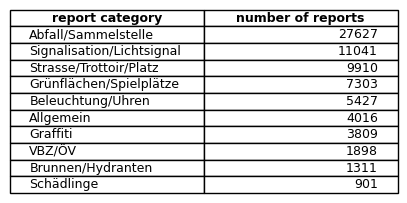

<Figure size 640x480 with 0 Axes>

In [43]:
fig, ax =plt.subplots(figsize=(5,1))
ax.axis("off")

#first I want to improve the readability of the column headers
improved_col_headers=[]
for col_header in nr_reports_per_category.columns:
    improved_col_headers.append(col_header.replace("_", " "))

# create the table
overview_table=ax.table(cellText=nr_reports_per_category.values,
         colLabels=improved_col_headers,
         loc="center",
         cellLoc="right")

#further improve aesthetics of the table:
for (row, col), cell in overview_table.get_celld().items():
    #make column titles bold
    if row==0:
        cell.set_text_props(weight="bold")
        continue #to avoid that the text of the column headers are oriented as the text in the cells

    #
    elif col==0:
        cell.get_text().set_ha("left") #set_ha=set_horizontal_alignment

export_result_to_png("Q4_table_nrreports_per_category")
plt.show()

plt.clf()


## 4. Visually display this statistics
The table is nice, but humans prefer to see such data visuallised. Therefore, I will create a bar chart and a pie chart to display the results.

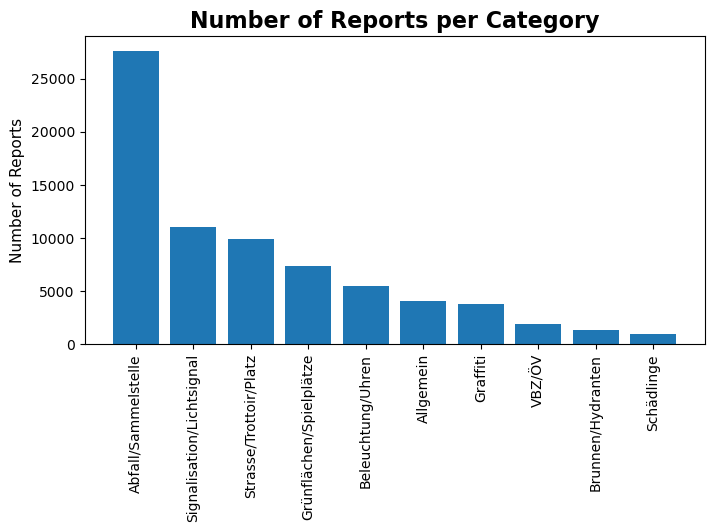

<Figure size 640x480 with 0 Axes>

In [71]:
# Bar Chart
fig, ax = plt.subplots(figsize=(8,4))

ax.bar(x=nr_reports_per_category["report_category"], height=nr_reports_per_category["number_of_reports"], zorder=1)
ax.set_title("Number of Reports per Category", fontsize=16, fontweight="bold")
ax.set_ylabel("Number of Reports", fontsize=11)

#rotate the x_labels:
ax.tick_params(axis="x", rotation=90)

export_result_to_png("Q4_barchart_nr_reports_per_category")
plt.show()
plt.clf()

'File was saved to ..\\outputs\\Q4_piechart_categories.png.'

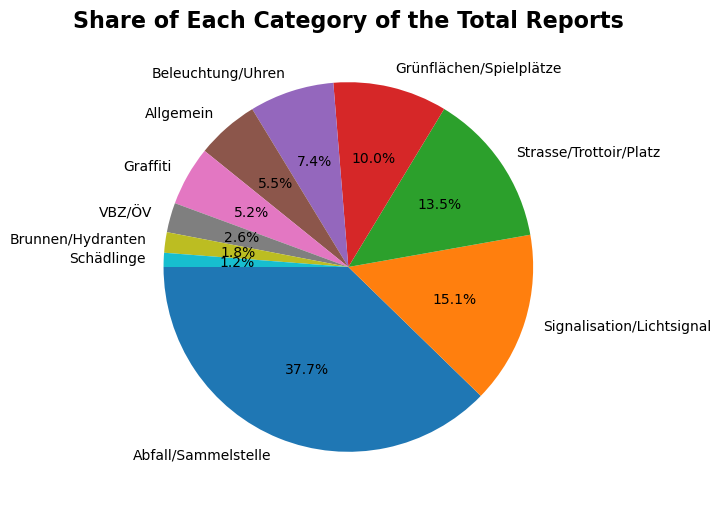

In [80]:
# Pie Chart
fig, ax=plt.subplots(figsize=(6,6))
ax.axis("off")

ax.pie(nr_reports_per_category["number_of_reports"], 
       labels=nr_reports_per_category["report_category"], 
       autopct='%1.1f%%', 
       startangle=180)

ax.set_title("Share of Each Category of the Total Reports", fontsize=16, fontweight="bold")

export_result_to_png("Q4_piechart_categories")

## 5. Subsequent Question (Q5): Which is the most common category per neighborhood?
Although the initial research question is answered by now, I started wondering whether the category "Abfall/Sammelstelle" is the most common category in every neighborhood.

In [90]:
# first sort the reports per neighborhood and per category:
reports_per_c_and_n=(reports_full_sjoin
    .groupby(["qname", "report_category"])
    .size()
    .reset_index(name="nr_reports")
    .sort_values(by="qname")
)
print(reports_per_c_and_n)

           qname            report_category  nr_reports
0      Affoltern        Abfall/Sammelstelle         790
1      Affoltern                  Allgemein         109
2      Affoltern          Beleuchtung/Uhren         247
3      Affoltern          Brunnen/Hydranten          30
4      Affoltern                   Graffiti         133
..           ...                        ...         ...
335  Wollishofen    Grünflächen/Spielplätze         371
336  Wollishofen                 Schädlinge          95
337  Wollishofen  Signalisation/Lichtsignal         413
338  Wollishofen     Strasse/Trottoir/Platz         388
339  Wollishofen                     VBZ/ÖV          51

[340 rows x 3 columns]


To get the maximum category per neighborhood, I used a for loop. Inside the loop I created a subset for each neighborhood, sorted it by highest value and appended the row to a list. This is certainly not the smoothest solution, but the best I could do without copy-pasting from ChatGPT. 

The retreived list has then to be converted into a dataframe. Then, it has to be merged with the quartiere gdf.

In [105]:
# get the maximum value per neighborhood: 
highest_report_category_per_neighborhood=[]

for neighborhood_name in reports_per_c_and_n["qname"].unique():
    subset=reports_per_c_and_n[reports_per_c_and_n["qname"]==neighborhood_name]
    subset=subset.sort_values(by="nr_reports", ascending=False)
    highest_report_category_per_neighborhood.append(subset.iloc[0])

# convert the retreived list into a df
highest_report_category_per_neighborhood=pd.DataFrame(highest_report_category_per_neighborhood)

highest_report_category_per_neighborhood.head(3)


,qname,report_category,nr_reports
0,Affoltern,Abfall/Sammelstelle,790
10,Albisrieden,Abfall/Sammelstelle,648
20,Alt-Wiedikon,Abfall/Sammelstelle,1293


In [114]:
#merge the newly created dataframe with the quartiere_geodataframe
quartiere_map=import_preprocessed_data("quartiere_map.gpkg")

quartiere_map=quartiere_map.merge(highest_report_category_per_neighborhood,
                    on="qname",
                    how="left")

#visually verify wheter the merge worked
quartiere_map.head(35)

The active geometry column of this geodataframe is called 'geometry'.


,qnr,qname,knr,kname,geometry,report_category,nr_reports
0,73,Hirslanden,7,Kreis 7,"POLYGON ((2684457.034 1246514.804, 2684466.315...",Abfall/Sammelstelle,480
1,83,Weinegg,8,Kreis 8,"POLYGON ((2684457.383 1246512.719, 2684458.291...",Abfall/Sammelstelle,256
2,82,Mühlebach,8,Kreis 8,"POLYGON ((2684269.913 1246566.796, 2684271.618...",Abfall/Sammelstelle,394
3,81,Seefeld,8,Kreis 8,"POLYGON ((2683794.254 1246609.895, 2683802.117...",Abfall/Sammelstelle,515
4,41,Werd,4,Kreis 4,"POLYGON ((2682651.888 1247587.653, 2682650.697...",Abfall/Sammelstelle,935
5,34,Sihlfeld,3,Kreis 3,"POLYGON ((2681620.924 1247666.669, 2681627.848...",Abfall/Sammelstelle,3164
6,91,Albisrieden,9,Kreis 9,"POLYGON ((2680246.801 1248184.959, 2680242.274...",Abfall/Sammelstelle,648
7,72,Hottingen,7,Kreis 7,"POLYGON ((2686439.052 1249239.332, 2686493.549...",Abfall/Sammelstelle,532
8,21,Wollishofen,2,Kreis 2,"POLYGON ((2683464.971 1243316.936, 2683455.914...",Abfall/Sammelstelle,876
9,61,Unterstrass,6,Kreis 6,"POLYGON ((2682138.424 1251265.833, 2682137.208...",Abfall/Sammelstelle,1128


## 6. Map of the subsequent Q5
The derived results are now mapped:

<Axes: >

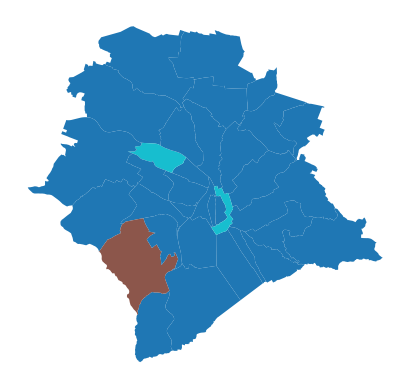

In [115]:
fig, ax=plt.subplots()
ax.axis("off")
quartiere_map.plot(ax=ax, column="report_category")
